# Sistema de OMR (Optical Mark Recognition - Reconhecimento Óptico de Marcas)

### Captura de dados que reconhece marcações de alunos feitas em documentos físicos, como "bolhas" preenchidas em provas.

### **Laboratório / Testes Visuais**

## Importar pacotes

In [68]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Carregar e obter dados da imagem

In [210]:
# Caminho da imagem

image_path = "imagens/7Branco_MariaFernanda.png"  # Nome da foto do gabarito

# Dados da imagem

# Dados da imagem
base = os.path.splitext(os.path.basename(image_path))[0]

if "_" in base:
    turma, nome = base.split("_", 1)
else:
    turma, nome = "SEM_TURMA", base  # fallback

print("Turma:", turma)
print("Nome:", nome)

Turma: 7Branco
Nome: MariaFernanda


## Pré-processamento da imagem: criação da imagem binarizada

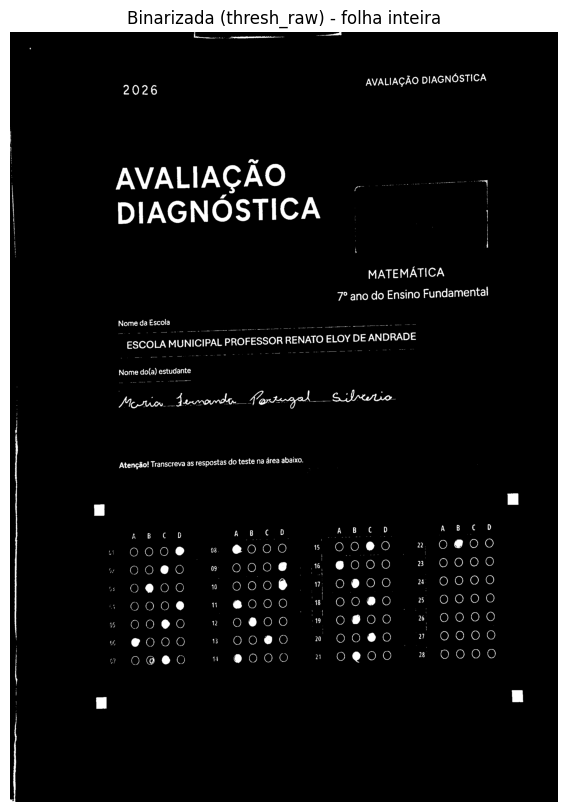

In [211]:
# Carregar imagem
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Não achei a imagem em: {image_path}")
orig = image.copy()

# Converter para escala de cinza
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Corrigir iluminação
background = cv2.GaussianBlur(gray, (101,101), 0)
normalized = cv2.divide(gray, background, scale=255)

# Aplicar threshold
_, thresh_raw = cv2.threshold(
    normalized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Para detectar bolhas (não mexe muito)
thresh_detect = thresh_raw.copy()

# Para medir preenchimento (CLOSE reforça marcação)
k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
thresh_fill = cv2.morphologyEx(thresh_raw, cv2.MORPH_CLOSE, k2)

# Mostrar imagem binarizada principal
plt.figure(figsize=(8,10))
plt.imshow(thresh_raw, cmap="gray")
plt.title("Binarizada (thresh_raw) - folha inteira")
plt.axis("off")
plt.show()

## Recortar automaticamente a região do gabarito (ROI): 
### Para recortar ROI é necessário uma imagem binarizada da folha inteira para encontrar os marcadores quadrados.

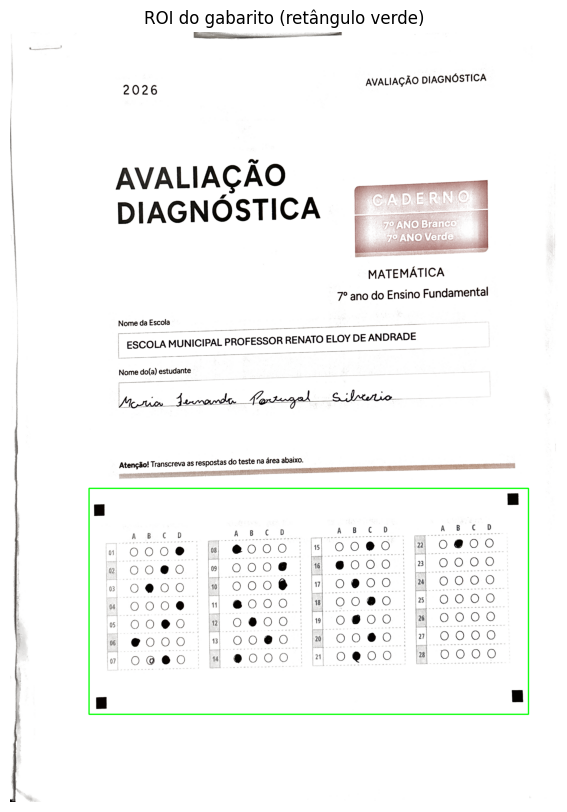

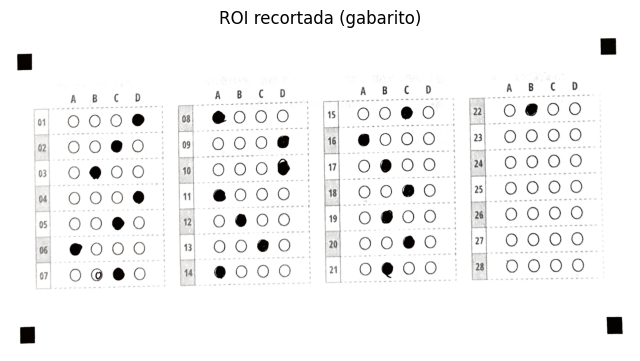

In [212]:
# 1) Encontrar contornos externos (quadradinhos marcadores)
cnts, _ = cv2.findContours(thresh_raw.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

H, W = thresh_raw.shape[:2]
cands = []

for c in cnts:
    area = cv2.contourArea(c)
    if area < 200:   # descarta lixo pequeno
        continue

    x, y, w, h = cv2.boundingRect(c)
    ar = w / float(h)

    # quadrado aproximadamente
    if not (0.80 <= ar <= 1.20):
        continue

    # tem que ser "bem quadrado" e razoavelmente grande
    if w < 10 or h < 10:
        continue

    # guardar (priorizar os da metade inferior da folha)
    cands.append((area, x, y, w, h))

# se tiver muita coisa, preferir candidatos da metade inferior
cands_bottom = [t for t in cands if t[2] > H * 0.35]
cands_use = cands_bottom if len(cands_bottom) >= 4 else cands

# pegar os 12 maiores e depois escolher 4 melhores
cands_use = sorted(cands_use, key=lambda t: t[0], reverse=True)[:12]

if len(cands_use) < 4:
    raise RuntimeError(f"Não consegui achar 4 marcadores quadrados. Achei só {len(cands_use)}.")

# 2) Escolher 4 marcadores que formam os cantos (heurística por posição)
# pega os centros
centers = []
for area, x, y, w, h in cands_use:
    cx = x + w/2
    cy = y + h/2
    centers.append((cx, cy, x, y, w, h, area))

# canto superior-esq = menor (cx+cy)
tl = min(centers, key=lambda t: t[0] + t[1])
# canto superior-dir = maior (cx - cy)
tr = max(centers, key=lambda t: t[0] - t[1])
# canto inferior-esq = menor (cx - cy)
bl = min(centers, key=lambda t: t[0] - t[1])
# canto inferior-dir = maior (cx+cy)
br = max(centers, key=lambda t: t[0] + t[1])

# 3) Definir ROI pelo retângulo desses 4 pontos
xs = [tl[2], tr[2] + tr[4], bl[2], br[2] + br[4]]
ys = [tl[3], tr[3], bl[3] + bl[5], br[3] + br[5]]

x1, x2 = int(max(0, min(xs) - 20)), int(min(W, max(xs) + 20))
y1, y2 = int(max(0, min(ys) - 20)), int(min(H, max(ys) + 20))

orig_roi = orig[y1:y2, x1:x2]
thresh_raw_roi = thresh_detect[y1:y2, x1:x2]
thresh_fill_roi = thresh_fill[y1:y2, x1:x2]

# DEBUG: desenhar retângulo na imagem original
dbg = orig.copy()
cv2.rectangle(dbg, (x1,y1), (x2,y2), (0,255,0), 4)

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))
plt.title("ROI do gabarito (retângulo verde)")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(orig_roi, cv2.COLOR_BGR2RGB))
plt.title("ROI recortada (gabarito)")
plt.axis("off")
plt.show()

## Detectar bolhas na ROI (contorno + Hough como fallback)

Candidatos (bordas): 128
Raio (modo/pico): 19.59797917604446
Bolhas detectadas (filtradas por raio): 111


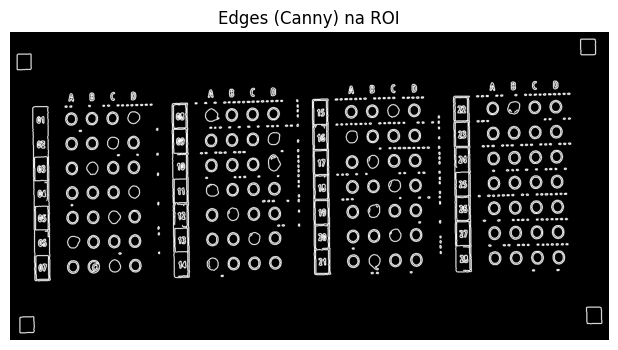

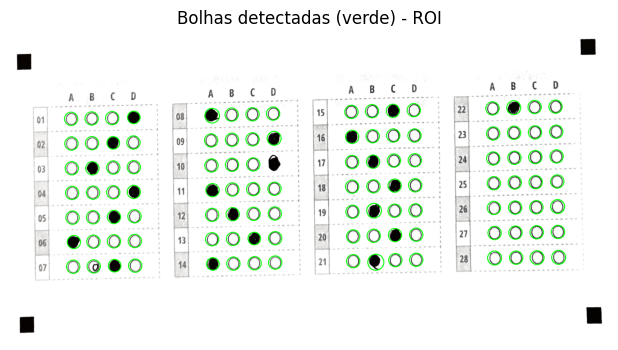

In [213]:
# 0) Melhor usar grayscale da ROI para Canny (fica mais estável que usar thresh)
gray_roi = cv2.cvtColor(orig_roi, cv2.COLOR_BGR2GRAY)
gray_roi = cv2.GaussianBlur(gray_roi, (7, 7), 0)

# 1) Canny (bordas)
edges = cv2.Canny(gray_roi, 50, 150)

# 2) Engrossar bordas um pouco (ajuda a fechar anéis)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
edges = cv2.dilate(edges, k, iterations=1)

# 3) Encontrar contornos nas bordas
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cands = []
r_list = []

for c in contours:
    area = cv2.contourArea(c)
    if area < 25:  # borda tem área pequena
        continue

    # círculo mínimo que "abraça" o contorno -> raio robusto
    (x0, y0), r = cv2.minEnclosingCircle(c)
    r = float(r)

    # filtros simples (ajuste fino aqui)
    if r < 8 or r > 25:   # faixa típica do seu layout (ajuste se precisar)
        continue

    # circularidade (bem tolerante)
    peri = cv2.arcLength(c, True)
    if peri == 0:
        continue
    circ = 4*np.pi*area/(peri*peri)
    if circ < 0.10:
        continue

    cands.append(c)
    r_list.append(r)

print("Candidatos (bordas):", len(cands))

# 4) filtro pelo raio mais comum (pico)
if len(r_list) == 0:
    bubble_contours = []
    print("Nenhuma bolha candidata encontrada.")
else:
    r_list = np.array(r_list)
    hist, bins = np.histogram(r_list, bins=40)
    i_peak = np.argmax(hist)
    r_mode = (bins[i_peak] + bins[i_peak+1]) / 2.0
    print("Raio (modo/pico):", r_mode)

    tol = 0.25 * r_mode  # 0.20 mais rígido / 0.35 mais permissivo

    bubble_contours = []
    for c in cands:
        (_, _), r = cv2.minEnclosingCircle(c)
        if abs(r - r_mode) <= tol:
            bubble_contours.append(c)

print("Bolhas detectadas (filtradas por raio):", len(bubble_contours))

# 5) Visualização
img_bubbles = orig_roi.copy()
for c in bubble_contours:
    (x0, y0), r = cv2.minEnclosingCircle(c)
    cv2.circle(img_bubbles, (int(x0), int(y0)), int(r), (0,255,0), 2)

plt.figure(figsize=(10,4))
plt.imshow(edges, cmap="gray")
plt.title("Edges (Canny) na ROI")
plt.axis("off")
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(cv2.cvtColor(img_bubbles, cv2.COLOR_BGR2RGB))
plt.title("Bolhas detectadas (verde) - ROI")
plt.axis("off")
plt.show()

## Filtrar bolhas preenchidas (fill consistente + Otsu 1D)

Limiar automático (thr score): 0.2714355773940379
Bolhas marcadas: 22


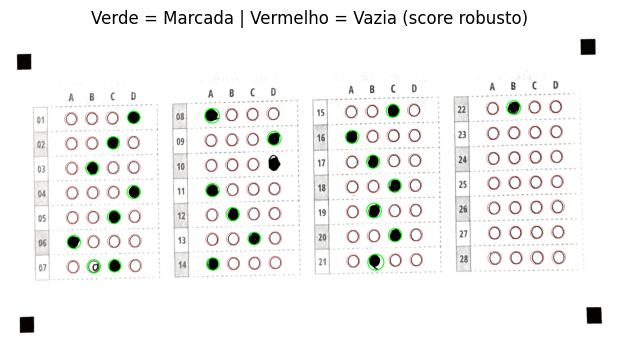

In [214]:
fills = []
bubble_info = []

# NÃO usar OPEN aqui
ink = thresh_raw_roi.copy()

for c in bubble_contours:
    (x0, y0), r = cv2.minEnclosingCircle(c)
    cx, cy = int(x0), int(y0)
    r = float(r)

    r_inner = int(max(1, r * 0.85))
    r_outer = int(max(1, r * 1.15))

    mask_in = np.zeros(ink.shape, dtype="uint8")
    cv2.circle(mask_in, (cx, cy), r_inner, 255, -1)

    mask_out = np.zeros(ink.shape, dtype="uint8")
    cv2.circle(mask_out, (cx, cy), r_outer, 255, -1)

    in_cnt = cv2.countNonZero(cv2.bitwise_and(ink, ink, mask=mask_in))
    out_cnt = cv2.countNonZero(cv2.bitwise_and(ink, ink, mask=mask_out))

    area_in = np.pi * (r_inner ** 2)
    area_out = np.pi * (r_outer ** 2)

    fill_in = (in_cnt / area_in) if area_in > 0 else 0.0
    fill_out = (out_cnt / area_out) if area_out > 0 else 0.0

    score = float(fill_in - 0.45 * fill_out)

    fills.append(score)
    bubble_info.append((cx, cy, int(r), score))

# --- limiar automático (Otsu 1D) adaptado para score que pode ser negativo ---
# normalizar score para 0..1 antes do hist
vals = np.array(fills, dtype=float)
vmin, vmax = float(vals.min()), float(vals.max())
if vmax - vmin < 1e-6:
    thr = 0.20
else:
    vals01 = (vals - vmin) / (vmax - vmin)

    hist, _ = np.histogram(vals01, bins=256, range=(0,1))
    total = hist.sum()
    sum_total = sum(i * hist[i] for i in range(256))

    sumB = 0
    wB = 0
    max_var = 0
    threshold_bin = 0

    for i in range(256):
        wB += hist[i]
        if wB == 0:
            continue
        wF = total - wB
        if wF == 0:
            break

        sumB += i * hist[i]
        mB = sumB / wB
        mF = (sum_total - sumB) / wF
        var_between = wB * wF * (mB - mF) ** 2

        if var_between > max_var:
            max_var = var_between
            threshold_bin = i

    thr01 = threshold_bin / 255.0
    thr01 = max(thr01, 0.20)

    # volta para score original
    thr = vmin + thr01 * (vmax - vmin)

print("Limiar automático (thr score):", thr)

# --- Visualização marcado vs vazio ---
marked = []
img_marked = orig_roi.copy()

for (cx, cy, r_int, score) in bubble_info:
    if score > thr:
        marked.append((cx, cy, r_int, score))
        cv2.circle(img_marked, (cx, cy), int(r_int), (0,255,0), 2)
    else:
        cv2.circle(img_marked, (cx, cy), int(r_int), (0,0,255), 1)

print("Bolhas marcadas:", len(marked))

plt.figure(figsize=(10,4))
plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
plt.title("Verde = Marcada | Vermelho = Vazia (score robusto)")
plt.axis("off")
plt.show()

## Extrair respostas A/B/C/D para as questões

In [215]:
# 1) Transformar bolhas detectadas em uma lista com centro e fill

# bubble_info: [(cx, cy, r, fill), ...]  -> já existe no código

# 2) Determinar coluna de cada bolha (4 colunas) usando k-means 1D (agrupando apenas por posição horizontal (x) do gabarito)

# Coordenadas x das bolhas
xs = np.array([b[0] for b in bubble_info]).reshape(-1, 1)

# KMeans com 4 colunas
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(xs)

# Ordenar colunas da esquerda para direita
centers = kmeans.cluster_centers_.flatten()
order = np.argsort(centers)

# Remapear labels para 0,1,2,3 (esquerda → direita)
remap = {old: new for new, old in enumerate(order)}
labels = np.array([remap[l] for l in labels])

# 3) Separar bolhas por coluna e ordenar por y (de cima para baixo)

cols = {i: [] for i in range(4)}
for (b, col) in zip(bubble_info, labels):
    cols[col].append(b)

for c in range(4):
    cols[c] = sorted(cols[c], key=lambda t: t[1])  # ordena por cy

# 4) Agrupar as bolhas por linhas usando KMeans também

answers = []

alt_map = {0:"A", 1:"B", 2:"C", 3:"D"}

for col in range(4):

    col_bubbles = cols[col]

    if len(col_bubbles) == 0:
        continue

    ys = np.array([b[1] for b in col_bubbles]).reshape(-1,1)

    kmeans_rows = KMeans(n_clusters=7, random_state=42, n_init=10)
    row_labels = kmeans_rows.fit_predict(ys)

    row_centers = kmeans_rows.cluster_centers_.flatten()
    row_order = np.argsort(row_centers)

    row_remap = {old:new for new, old in enumerate(row_order)}
    row_labels = np.array([row_remap[l] for l in row_labels])

    # Para cada linha
    for row in range(7):

        row_bubbles = [b for b, rl in zip(col_bubbles, row_labels) if rl == row]

        if len(row_bubbles) < 4:
            # algo estranho nessa linha
            answers.append((col*7 + row + 1, None))
            continue

        # ordenar por X (só para ter algo consistente)
        row_bubbles = sorted(row_bubbles, key=lambda t: t[0])

        # Se vierem muitas bolhas, vamos "encaixar" em 4 slots (A-D) via KMeans no X
        xs_row = np.array([b[0] for b in row_bubbles]).reshape(-1, 1)

        kmeans_abcd = KMeans(n_clusters=4, random_state=42, n_init=10)
        lab_abcd = kmeans_abcd.fit_predict(xs_row)

        cent_abcd = kmeans_abcd.cluster_centers_.flatten()
        ord_abcd = np.argsort(cent_abcd)
        remap_abcd = {old: new for new, old in enumerate(ord_abcd)}
        lab_abcd = np.array([remap_abcd[l] for l in lab_abcd])

        # Para cada alternativa (0..3), escolhe a bolha mais próxima do centro daquele grupo
        slots = []
        for j in range(4):
            group = [b for b, lj in zip(row_bubbles, lab_abcd) if lj == j]
            if len(group) == 0:
                slots.append(None)
                continue
            cx_target = cent_abcd[ord_abcd[j]]
            best = min(group, key=lambda t: abs(t[0] - cx_target))
            slots.append(best)

        # Se faltou algum slot, não dá pra decidir com segurança
        if any(s is None for s in slots):
            answers.append((col*7 + row + 1, None))
            continue

        # Agora slots = [A,B,C,D] garantido
        fills = [s[3] for s in slots]
        max_i = int(np.argmax(fills))
        sorted_fills = sorted(fills, reverse=True)

        # Regra híbrida: limiar mínimo + (opcional) diferença pequena
        thr_abs = max(thr, 0.18)   # como seu thr deu 0.2, fica 0.2
        delta = 0.05               # diferença mínima (bem menos agressivo que 0.08)

        if sorted_fills[0] >= thr_abs:
            # se passar o mínimo, aceita
            # se quiser ser um pouco mais rígido, pode exigir delta também:
            # if sorted_fills[0] >= thr_abs and (sorted_fills[0] - sorted_fills[1]) >= delta:
            ans = alt_map[max_i]
        else:
            ans = None

        q_num = col*7 + row + 1
        answers.append((q_num, ans))

# 5) Ordenar por número da questão e pegar só as 22 usadas

answers = sorted(answers, key=lambda x: x[0])
answers_22 = answers[:22]

print("Respostas (1–22):")
for q, a in answers_22:
    print(f"{q:02d}: {a}")

Respostas (1–22):
01: D
02: C
03: B
04: D
05: C
06: A
07: C
08: A
09: D
10: None
11: A
12: B
13: C
14: A
15: C
16: A
17: B
18: C
19: B
20: C
21: B
22: B


## Gabarito 

In [216]:
gabarito_lista = ["B","C","C","C","C","A","B","A","C","D",
                  "C","B","C","B","C","A","B","C","B","C",
                  "D","B"]

gabarito = {i+1: gabarito_lista[i] for i in range(len(gabarito_lista))}

## Comparar com as respostas detectadas

In [217]:
acertos = 0
erros = []
brancos = []

for q, resp in answers_22:
    correta = gabarito.get(q)

    if resp is None:
        brancos.append(q)
    elif resp == correta:
        acertos += 1
    else:
        erros.append(q)

print("Acertos:", acertos)
print("Erros:", erros)
print("Em branco:", brancos)
print("Nota:", acertos)

nota = acertos
percentual = (acertos / len(gabarito)) * 100

print(f"Nota: {nota}/22")
print(f"Percentual: {percentual:.1f}%")

Acertos: 13
Erros: [1, 3, 4, 7, 9, 11, 14, 21]
Em branco: [10]
Nota: 13
Nota: 13/22
Percentual: 59.1%


In [185]:
resultado = {
    "acertos": acertos,
    "erros": erros,
    "brancos": brancos,
    "nota": nota,
    "percentual": percentual
}